- Repetindo a mesma arquitetura/pipeline do modelo xgb:

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import itertools
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import cross_val_score

In [2]:
# dataframe vindo do notebook anterior
caminho_arquivo = 'nfl_features_ml_2021_2025.parquet'

try:
    df_ml = pd.read_parquet(caminho_arquivo)
    print(f"Dataset carregado com sucesso! Total de jogos: {len(df_ml)}")
except Exception as e:
    print("Tentando carregar CSV como fallback...")
    df_ml = pd.read_csv('nfl_features_ml_2021_2025.csv')

Dataset carregado com sucesso! Total de jogos: 1339


In [11]:
# 1. Preparando os "Interruptores" de Features (Padrão Original do GridSearch)
blocos_features = {
    'pts_last3': ['home_offense_pts_last3', 'home_defense_pts_last3', 'away_offense_pts_last3', 'away_defense_pts_last3'],
    'pts_season': ['home_offense_pts_season', 'home_defense_pts_season', 'away_offense_pts_season', 'away_defense_pts_season'],
    'ypp_last3': ['home_yards_per_play_last3', 'away_yards_per_play_last3'],
    'ypp_season': ['home_yards_per_play_season', 'away_yards_per_play_season'],
    'turnovers_last3': ['home_turnovers_last3', 'away_turnovers_last3'],
    'turnovers_season': ['home_turnovers_season', 'away_turnovers_season'],
    'yards_last3': ['home_total_yards_last3', 'away_total_yards_last3'],
    'yards_season': ['home_total_yards_season', 'away_total_yards_season']
}

# Separação cronológica (O Optuna treina só até 2024, teste é sagrado!)
df_train = df_ml[df_ml['season'] < 2025]
df_test = df_ml[df_ml['season'] == 2025]
y_train = df_train['target']
y_test = df_test['target']

# 2. A Função Objetivo (O Cassino do Optuna)
def objective(trial):
    # Passo A: O Optuna escolhe quais blocos de features LIGAR (True) ou DESLIGAR (False)
    features_ativas = []
    for nome_bloco, colunas in blocos_features.items():
        if trial.suggest_categorical(f'usar_{nome_bloco}', [True, False]):
            features_ativas.extend(colunas)
            
    # Se a IA desligar absolutamente todas as colunas, abortamos a tentativa para não dar erro
    if len(features_ativas) == 0:
        raise optuna.TrialPruned() 
        
    X_train_opt = df_train[features_ativas]
    
    # Passo B: O Optuna escolhe a calibração do motor (Hiperparâmetros para Random Forest)
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42
    }
    
    # Passo C: Treinamento interno usando Validação Cruzada (Cross-Validation)
    rf_opt = RandomForestClassifier(**param)
    scores = cross_val_score(rf_opt, X_train_opt, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    
    # A IA precisa saber qual foi a nota média para aprender o que funciona
    return scores.mean()

# Escondendo os logs detalhados do Optuna para não poluir a tela inteira (ele fala muito)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Iniciando a Otimização Conjunta com Optuna. Explorando o multiverso da NFL com a Floresta...")

# 3. O Maestro: Criando o estudo para maximizar a Acurácia
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100) # 100 gerações é um excelente número

print("\n=== RESULTADO DA OTIMIZAÇÃO (OPTUNA + RANDOM FOREST) ===")
print(f"Melhor Acurácia no Treino (Cross-Validation): {study.best_value:.4f}")
print("\nMelhor Configuração Encontrada pela IA:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Iniciando a Otimização Conjunta com Optuna. Explorando o multiverso da NFL com a Floresta...



=== RESULTADO DA OTIMIZAÇÃO (OPTUNA + RANDOM FOREST) ===
Melhor Acurácia no Treino (Cross-Validation): 0.6340

Melhor Configuração Encontrada pela IA:
  usar_pts_last3: True
  usar_pts_season: True
  usar_ypp_last3: False
  usar_ypp_season: True
  usar_turnovers_last3: False
  usar_turnovers_season: False
  usar_yards_last3: False
  usar_yards_season: False
  n_estimators: 200
  max_depth: 3
  min_samples_leaf: 6
  max_features: log2


In [12]:
# 1. As exatas features que o Optuna mandou ligar para a Floresta
features_optuna_rf = [
    # pts_last3
    'home_offense_pts_last3', 'home_defense_pts_last3', 'away_offense_pts_last3', 'away_defense_pts_last3',
    # pts_season
    'home_offense_pts_season', 'home_defense_pts_season', 'away_offense_pts_season', 'away_defense_pts_season',
    # ypp_season
    'home_yards_per_play_season', 'away_yards_per_play_season'
]

# 2. Re-separando Treino e Teste
X_train_opt_rf = df_train[features_optuna_rf]
X_test_opt_rf = df_test[features_optuna_rf]

In [13]:
# 3. O Motor calibrado pela IA
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=6,
    max_features='log2',
    random_state=42
)

# Treinamento Oficial
rf_final.fit(X_train_opt_rf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [14]:
# 4. Previsões para 2025
rf_opt_preds = rf_final.predict(X_test_opt_rf)
rf_opt_probs = rf_final.predict_proba(X_test_opt_rf)[:, 1]

In [15]:
def imprimir_raio_x_modelo(nome_modelo, y_true, y_pred, y_prob):
    print(f"=== {nome_modelo} ===")
    print(f"Acurácia : {accuracy_score(y_true, y_pred):.2%}")
    print(f"Precisão : {precision_score(y_true, y_pred):.2%}")
    print(f"Recall   : {recall_score(y_true, y_pred):.2%}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.2%}")
    
    # ROC AUC exige que as duas classes (0 e 1) estejam presentes no y_true para não dar erro
    if len(np.unique(y_true)) > 1:
        print(f"ROC AUC  : {roc_auc_score(y_true, y_prob):.2%}")
    else:
        print(f"ROC AUC  : N/A (Apenas uma classe no filtro)")
    print("=" * 40)

In [16]:
# exibindo os resultados do modelo em todos os jogos (Acurácia Bruta)
imprimir_raio_x_modelo("Random Forest + Optuna (Acurácia Bruta)", y_test, rf_opt_preds, rf_opt_probs)

=== Random Forest + Optuna (Acurácia Bruta) ===
Acurácia : 57.93%
Precisão : 60.53%
Recall   : 63.01%
F1-Score : 61.74%
ROC AUC  : 64.45%


In [17]:
# definindo as fronteiras do Toss-Up (jogos imprevisíveis)
limite_inferior = 0.45
limite_superior = 0.55

def aplicar_filtro_tossup(nome_modelo, y_true, probs):
    y_true_array = np.array(y_true)
    probs_array = np.array(probs)
    
    # filtro: Pega só onde o modelo tem convicção (< 45% ou > 55%)
    jogos_confiantes = (probs_array < limite_inferior) | (probs_array > limite_superior)
    
    y_true_filtrado = y_true_array[jogos_confiantes]
    probs_filtrado = probs_array[jogos_confiantes]
    
    # gera a previsão dura (0 ou 1) para as métricas
    previsoes_finais = (probs_filtrado > 0.50).astype(int)
    
    total_jogos = len(y_true)
    jogos_apostados = len(y_true_filtrado)
    jogos_ignorados = total_jogos - jogos_apostados
    
    print(f"\n=== {nome_modelo} (Filtro Toss-Up 45%-55%) ===")
    
    if jogos_apostados == 0:
        print("O modelo não teve confiança em NENHUM jogo!")
        print("-" * 40)
        return
        
    print(f"Jogos Avaliados: {jogos_apostados}/{total_jogos} | Ignorados: {jogos_ignorados} ({jogos_ignorados/total_jogos:.1%})")
    
    # chama a função reaproveitada (passando um texto descritivo para o título interno)
    imprimir_raio_x_modelo("Métricas Filtradas", y_true_filtrado, previsoes_finais, probs_filtrado)

# aplica a função apenas para a Random Forest
aplicar_filtro_tossup("Random Forest + Optuna", y_test, rf_opt_probs)


=== Random Forest + Optuna (Filtro Toss-Up 45%-55%) ===
Jogos Avaliados: 202/271 | Ignorados: 69 (25.5%)
=== Métricas Filtradas ===
Acurácia : 60.89%
Precisão : 64.29%
Recall   : 70.43%
F1-Score : 67.22%
ROC AUC  : 67.87%


=== RANKING DE IMPORTÂNCIA DAS FEATURES (Random Forest) ===


,Feature,Importancia
0,away_offense_pts_season,0.191754
1,away_yards_per_play_season,0.190580
2,home_offense_pts_season,0.152945
3,home_offense_pts_last3,0.124894
4,home_yards_per_play_season,0.105755
5,away_offense_pts_last3,0.088434
6,home_defense_pts_last3,0.045507
7,away_defense_pts_season,0.037959
8,home_defense_pts_season,0.034071
9,away_defense_pts_last3,0.028101


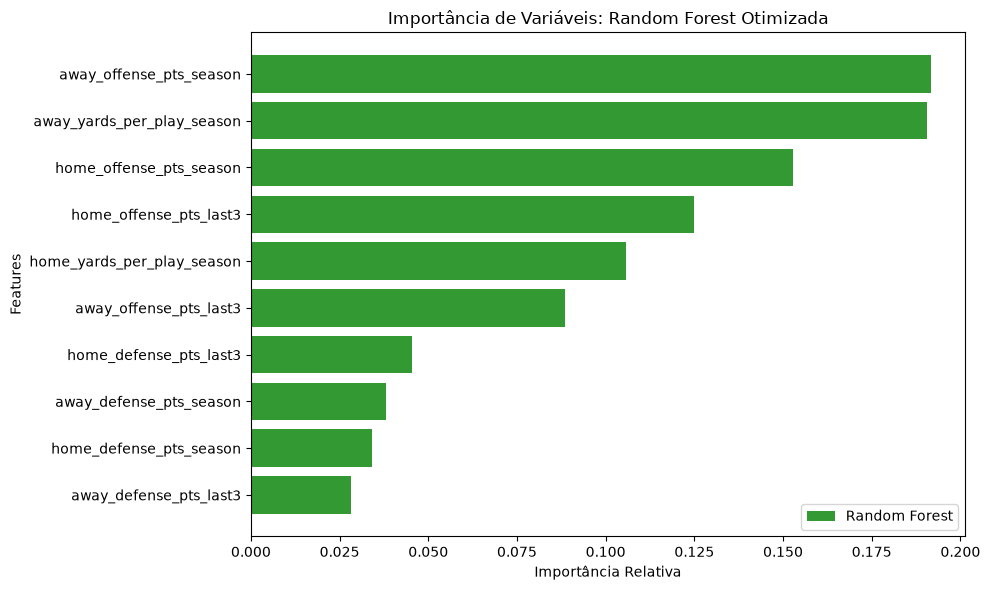

In [18]:
# Garante que temos a lista com o nome de todas as colunas de treino
features_names = [col for col in X_train_opt_rf.columns]

# 1. Extraindo a importância da Random Forest
importancia_rf = rf_final.feature_importances_

# 2. Montando um DataFrame para facilitar a visualização e ordenação
df_importancia = pd.DataFrame({
    'Feature': features_names,
    'Importancia': importancia_rf
})

# Ordenando pela importância
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).reset_index(drop=True)

print("=== RANKING DE IMPORTÂNCIA DAS FEATURES (Random Forest) ===")
display(df_importancia)

# 3. Gráfico visual para achar os protagonistas
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Feature'], df_importancia['Importancia'], color='green', alpha=0.8, label='Random Forest')
plt.xlabel('Importância Relativa')
plt.ylabel('Features')
plt.title('Importância de Variáveis: Random Forest Otimizada')
plt.gca().invert_yaxis() # Deixa a mais importante no topo
plt.legend()
plt.tight_layout()
plt.show()